## Torso Kinematics

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def Rx(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[1,0,0],[0,c,-s],[0,s,c]])
def Ry(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c,0,s],[0,1,0],[-s,0,c]])
def rot_axis(axis, angle):
    axis = axis / np.linalg.norm(axis)
    x, y, z = axis
    c, s = np.cos(angle), np.sin(angle)
    C = 1 - c
    return np.array([
        [c+x*x*C, x*y*C-z*s, x*z*C+y*s],
        [y*x*C+z*s, c+y*y*C, y*z*C-x*s],
        [z*x*C-y*s, z*y*C+x*s, c+z*z*C]
    ])


In [2]:
# Lengths
l_fixed = 25.0
l_crank = 75.0
l_rod   = 115.0

# Spacing
l_spacing_crank = 80.0
l_spacing_rod   = 80.0
l_spacing_base  = 80.0
l_spacing_torso = 80.0
l_diff = l_rod - l_fixed

crank_angle = np.radians(0.0)
rod_angle   = np.radians(90.0)

O     = np.array([ 0.0,                                                     0.0,                     0.0                                  ])
rA1_H = np.array([ 0.0,                                                     +l_spacing_crank/2.0,    l_diff + l_crank*np.sin(crank_angle) ])
rA2_H = np.array([ 0.0,                                                     -l_spacing_crank/2.0,    l_diff + l_crank*np.sin(crank_angle) ])
rB1_H = np.array([ l_crank*np.cos(crank_angle),                             +l_spacing_rod/2.0,      l_diff                               ])
rB2_H = np.array([ l_crank*np.cos(crank_angle),                             -l_spacing_rod/2.0,      l_diff                               ])
rC1_H = np.array([ l_crank*np.cos(crank_angle) + l_rod*np.cos(rod_angle),   +l_spacing_base/2.0,     -l_fixed                             ])
rC2_H = np.array([ l_crank*np.cos(crank_angle) + l_rod*np.cos(rod_angle),   -l_spacing_base/2.0,     -l_fixed                             ])
rD1_H = np.array([ 0.0,                                                     +l_spacing_torso/2.0,    0.0                                  ])
rD2_H = np.array([ 0.0,                                                     -l_spacing_torso/2.0,    0.0                                  ])


In [3]:
def solve_theta(rC, rA, rB, lrod, axis):
    v = rC - rA
    d = rB - rA
    RHS = (np.dot(v,v) + np.dot(d,d) - lrod**2)/2

    u = axis / np.linalg.norm(axis)
    d_par  = u*np.dot(u,d)
    d_perp = d - d_par

    a = np.dot(v, d_perp)
    b = np.dot(v, np.cross(u,d))
    c = RHS - np.dot(v,d_par)

    D = a*a + b*b
    disc = b*b*c*c - D*(c*c - a*a)
    if disc < 0:
        return []

    root = np.sqrt(disc)
    sols = []

    for sth in [(b*c+root)/D, (b*c-root)/D]:
        if abs(sth) <= 1:
            cth = (c - b*sth)/a # if abs(a)>1e-12 else np.sqrt(1-sth*sth)
            sols.append(np.arctan2(sth, cth))
    return sols


In [4]:

def set_equal_aspect(ax, points):
    all_pts = np.array(list(points.values()))
    x, y, z = all_pts[:,0], all_pts[:,1], all_pts[:,2]
    max_range = np.array([x.max()-x.min(),
                          y.max()-y.min(),
                          z.max()-z.min()]).max() / 2.0
    mid_x = (x.max() + x.min()) * 0.5
    mid_y = (y.max() + y.min()) * 0.5
    mid_z = (z.max() + z.min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
def plot_plane(ax, p1, p2, p3, p4, color='cyan', alpha=0.5):
    verts = [[p1, p2, p3, p4]]
    plane = Poly3DCollection(verts, alpha=alpha,
                             facecolor=color, edgecolor='k')
    ax.add_collection3d(plane)
def draw_axes(ax, origin=(0,0,0), L=0.1):
    ox, oy, oz = origin

    # X axis – Red
    ax.quiver(ox, oy, oz, L, 0, 0, color='r')
    ax.text(ox+L, oy, oz, 'X', color='r')

    # Y axis – Green
    ax.quiver(ox, oy, oz, 0, L, 0, color='g')
    ax.text(ox, oy+L, oz, 'Y', color='g')

    # Z axis – Blue
    ax.quiver(ox, oy, oz, 0, 0, L, color='b')
    ax.text(ox, oy, oz+L, 'Z', color='b')
def visualize_mechanism(points):

    fig = plt.figure(figsize=(15, 5))
    fig.canvas.manager.set_window_title("Torso RSU mech - parallel")

    def plot_mechanism(ax):

        for name, color in zip(
            ["O","A1","A2","B1","B2","C1","C2","D1","D2",
             "A1H","A2H","B1H","B2H","D1H","D2H"],
            ['r','r','r','r','r','r','r','r','r',
             'b','b','b','b','b','b']):

            ax.scatter(*points[name], c=color, label=name, s=30)

        links = [("A1","B1"),("A2","B2"),("B1","C1"),("B2","C2"),
                 ("A1","A2"),("D1","O"),("D2","O"),
                 ("A1","D1"),("A2","D2")]

        fixed = [("C1","C2"),("C1","D1H"),("C2","D2H"),("D1H","D2H")]

        Home = [("O","D1H"), ("O","D2H"), ("A1H","A2H"), ("A1H","B1H"),
                ("B1H","C1"), ("B2H","C2"), ("A2H","B2H"),
                ("D1H","A1H"),("D2H","A2H")]

        for p1,p2 in links:
            ax.plot([points[p1][0], points[p2][0]],
                    [points[p1][1], points[p2][1]],
                    [points[p1][2], points[p2][2]], 'k-', linewidth=2)

        for p1,p2 in fixed:
            ax.plot([points[p1][0], points[p2][0]],
                    [points[p1][1], points[p2][1]],
                    [points[p1][2], points[p2][2]], 'b-', linewidth=2)

        for p1,p2 in Home:
            ax.plot([points[p1][0], points[p2][0]],
                    [points[p1][1], points[p2][1]],
                    [points[p1][2], points[p2][2]], 'g--', linewidth=2)

        ax.set_xlabel("X axis")
        ax.set_ylabel("Y axis")
        ax.set_zlabel("Z axis")
        ax.set_proj_type('ortho')
        set_equal_aspect(ax, points)

        draw_axes(ax, origin=(0,0,0), L=20)

    ax1 = fig.add_subplot(131, projection='3d')
    plot_mechanism(ax1)
    ax1.view_init(0, 90)

    ax2 = fig.add_subplot(132, projection='3d')
    plot_mechanism(ax2)
    ax2.view_init(20, 45)

    ax3 = fig.add_subplot(133, projection='3d')
    plot_mechanism(ax3)
    ax3.view_init(0, 0)

    plot_plane(ax1, points["A1"], points["A2"], points["D2"], points["D1"],
               color='yellow', alpha=0.5)
    plot_plane(ax1, points["D1H"], points["C1"], points["C2"], points["D2H"],
               color='cyan', alpha=0.5)

    plot_plane(ax2, points["A1"], points["A2"], points["D2"], points["D1"],
               color='yellow', alpha=0.5)
    plot_plane(ax2, points["D1H"], points["C1"], points["C2"], points["D2H"],
               color='cyan', alpha=0.5)

    plt.tight_layout()
    plt.show()
def solve_and_plot(roll_deg, pitch_deg):

    pitch = np.radians(pitch_deg)
    roll  = np.radians(roll_deg)

    R = Ry(pitch) @ Rx(roll)

    # Rotated points
    rA1   = R @ rA1_H
    rA2   = R @ rA2_H
    rB1_i = R @ rB1_H
    rB2_i = R @ rB2_H
    rD1   = R @ rD1_H
    rD2   = R @ rD2_H

    # Rotation axis
    axis = rA1 - rA2
    axis /= np.linalg.norm(axis)

    # IK
    theta1_candidates = solve_theta(rC1_H, rA1, rB1_i, l_rod, axis)
    theta2_candidates = solve_theta(rC2_H, rA2, rB2_i, l_rod, axis)

    if not theta1_candidates or not theta2_candidates:
        print("❌ No IK solution")
        return

    theta1 = theta1_candidates[1]
    theta2 = theta2_candidates[1]

    rB1 = rA1 + rot_axis(axis, theta1) @ (rB1_i - rA1)
    rB2 = rA2 + rot_axis(axis, theta2) @ (rB2_i - rA2)

    print(f"Roll = {roll_deg}°Pitch = {pitch_deg}°, \n")
    print(f"θ1 = {np.degrees(theta1):.6f}°")
    print(f"θ2 = {np.degrees(theta2):.6f}°")

    points = {
        "O"  : O,
        "A1" : rA1,   "A2" : rA2,
        "B1" : rB1,   "B2" : rB2,
        "C1" : rC1_H, "C2" : rC2_H,
        "D1" : rD1,   "D2" : rD2,
        "A1H": rA1_H, "A2H": rA2_H,
        "B1H": rB1_H, "B2H": rB2_H,
        "D1H": rD1_H, "D2H": rD2_H
    }

    visualize_mechanism(points)

Roll = 15.0°Pitch = 0.0°, 

θ1 = 7.484842°
θ2 = -8.501914°


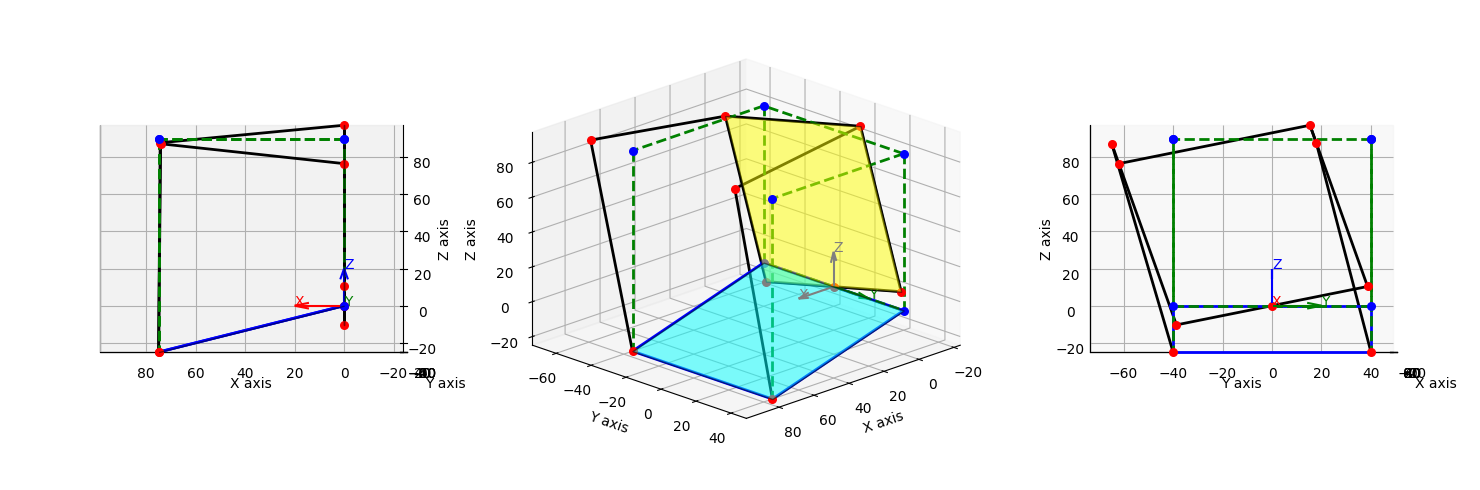

In [5]:
solve_and_plot(roll_deg=15.0, pitch_deg=0.0)

### Workspace Analysis

In [6]:
def is_feasible(pitch_deg, roll_deg):
    pitch = np.radians(pitch_deg)
    roll  = np.radians(roll_deg)

    R = Ry(pitch) @ Rx(roll)

    # Rotate points
    rA1 = R @ rA1_H
    rA2 = R @ rA2_H
    rB1_i = R @ rB1_H
    rB2_i = R @ rB2_H

    # Rotation axis
    axis = rA1 - rA2
    axis /= np.linalg.norm(axis)

    # IK solve
    theta1 = solve_theta(rC1_H, rA1, rB1_i, l_rod, axis)
    theta2 = solve_theta(rC2_H, rA2, rB2_i, l_rod, axis)

    return bool(theta1) and bool(theta2)

In [7]:
pitch_vals = np.linspace(-90, 90, 200)
roll_vals  = np.linspace(-90, 90, 200)

feasible_x, feasible_y = [], []
infeasible_x, infeasible_y = [], []

for pitch in pitch_vals:
    for roll in roll_vals:
        if is_feasible(pitch, roll):
            feasible_x.append(pitch)
            feasible_y.append(roll)
        else:
            infeasible_x.append(pitch)
            infeasible_y.append(roll)

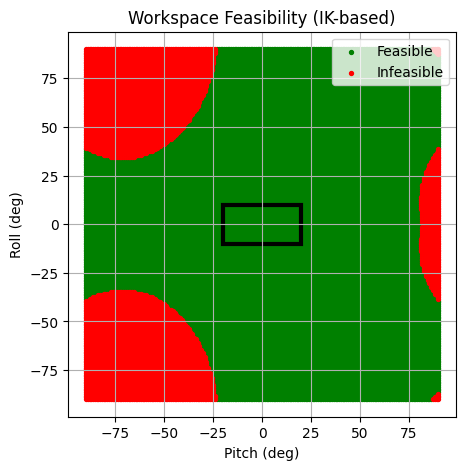

In [8]:

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(feasible_x, feasible_y, c='green', s=8, label="Feasible")
ax.scatter(infeasible_x, infeasible_y, c='red', s=8, label="Infeasible")

#  Target workspace box
target_pitch_min, target_pitch_max = -20, 20
target_roll_min, target_roll_max   = -10, 10

rect = patches.Rectangle(
    (target_pitch_min, target_roll_min),
    target_pitch_max - target_pitch_min,
    target_roll_max - target_roll_min,
    linewidth=3,
    edgecolor='black',
    facecolor='none'
)

ax.add_patch(rect)

ax.set_xlabel("Pitch (deg)")
ax.set_ylabel("Roll (deg)")
ax.set_title("Workspace Feasibility (IK-based)")
ax.legend()
ax.grid(True)

plt.show()
